In [1]:
import os

os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

from importlib import reload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import utils.paths as paths

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


Loading dataset from disk:   0%|          | 0/60 [00:00<?, ?it/s]

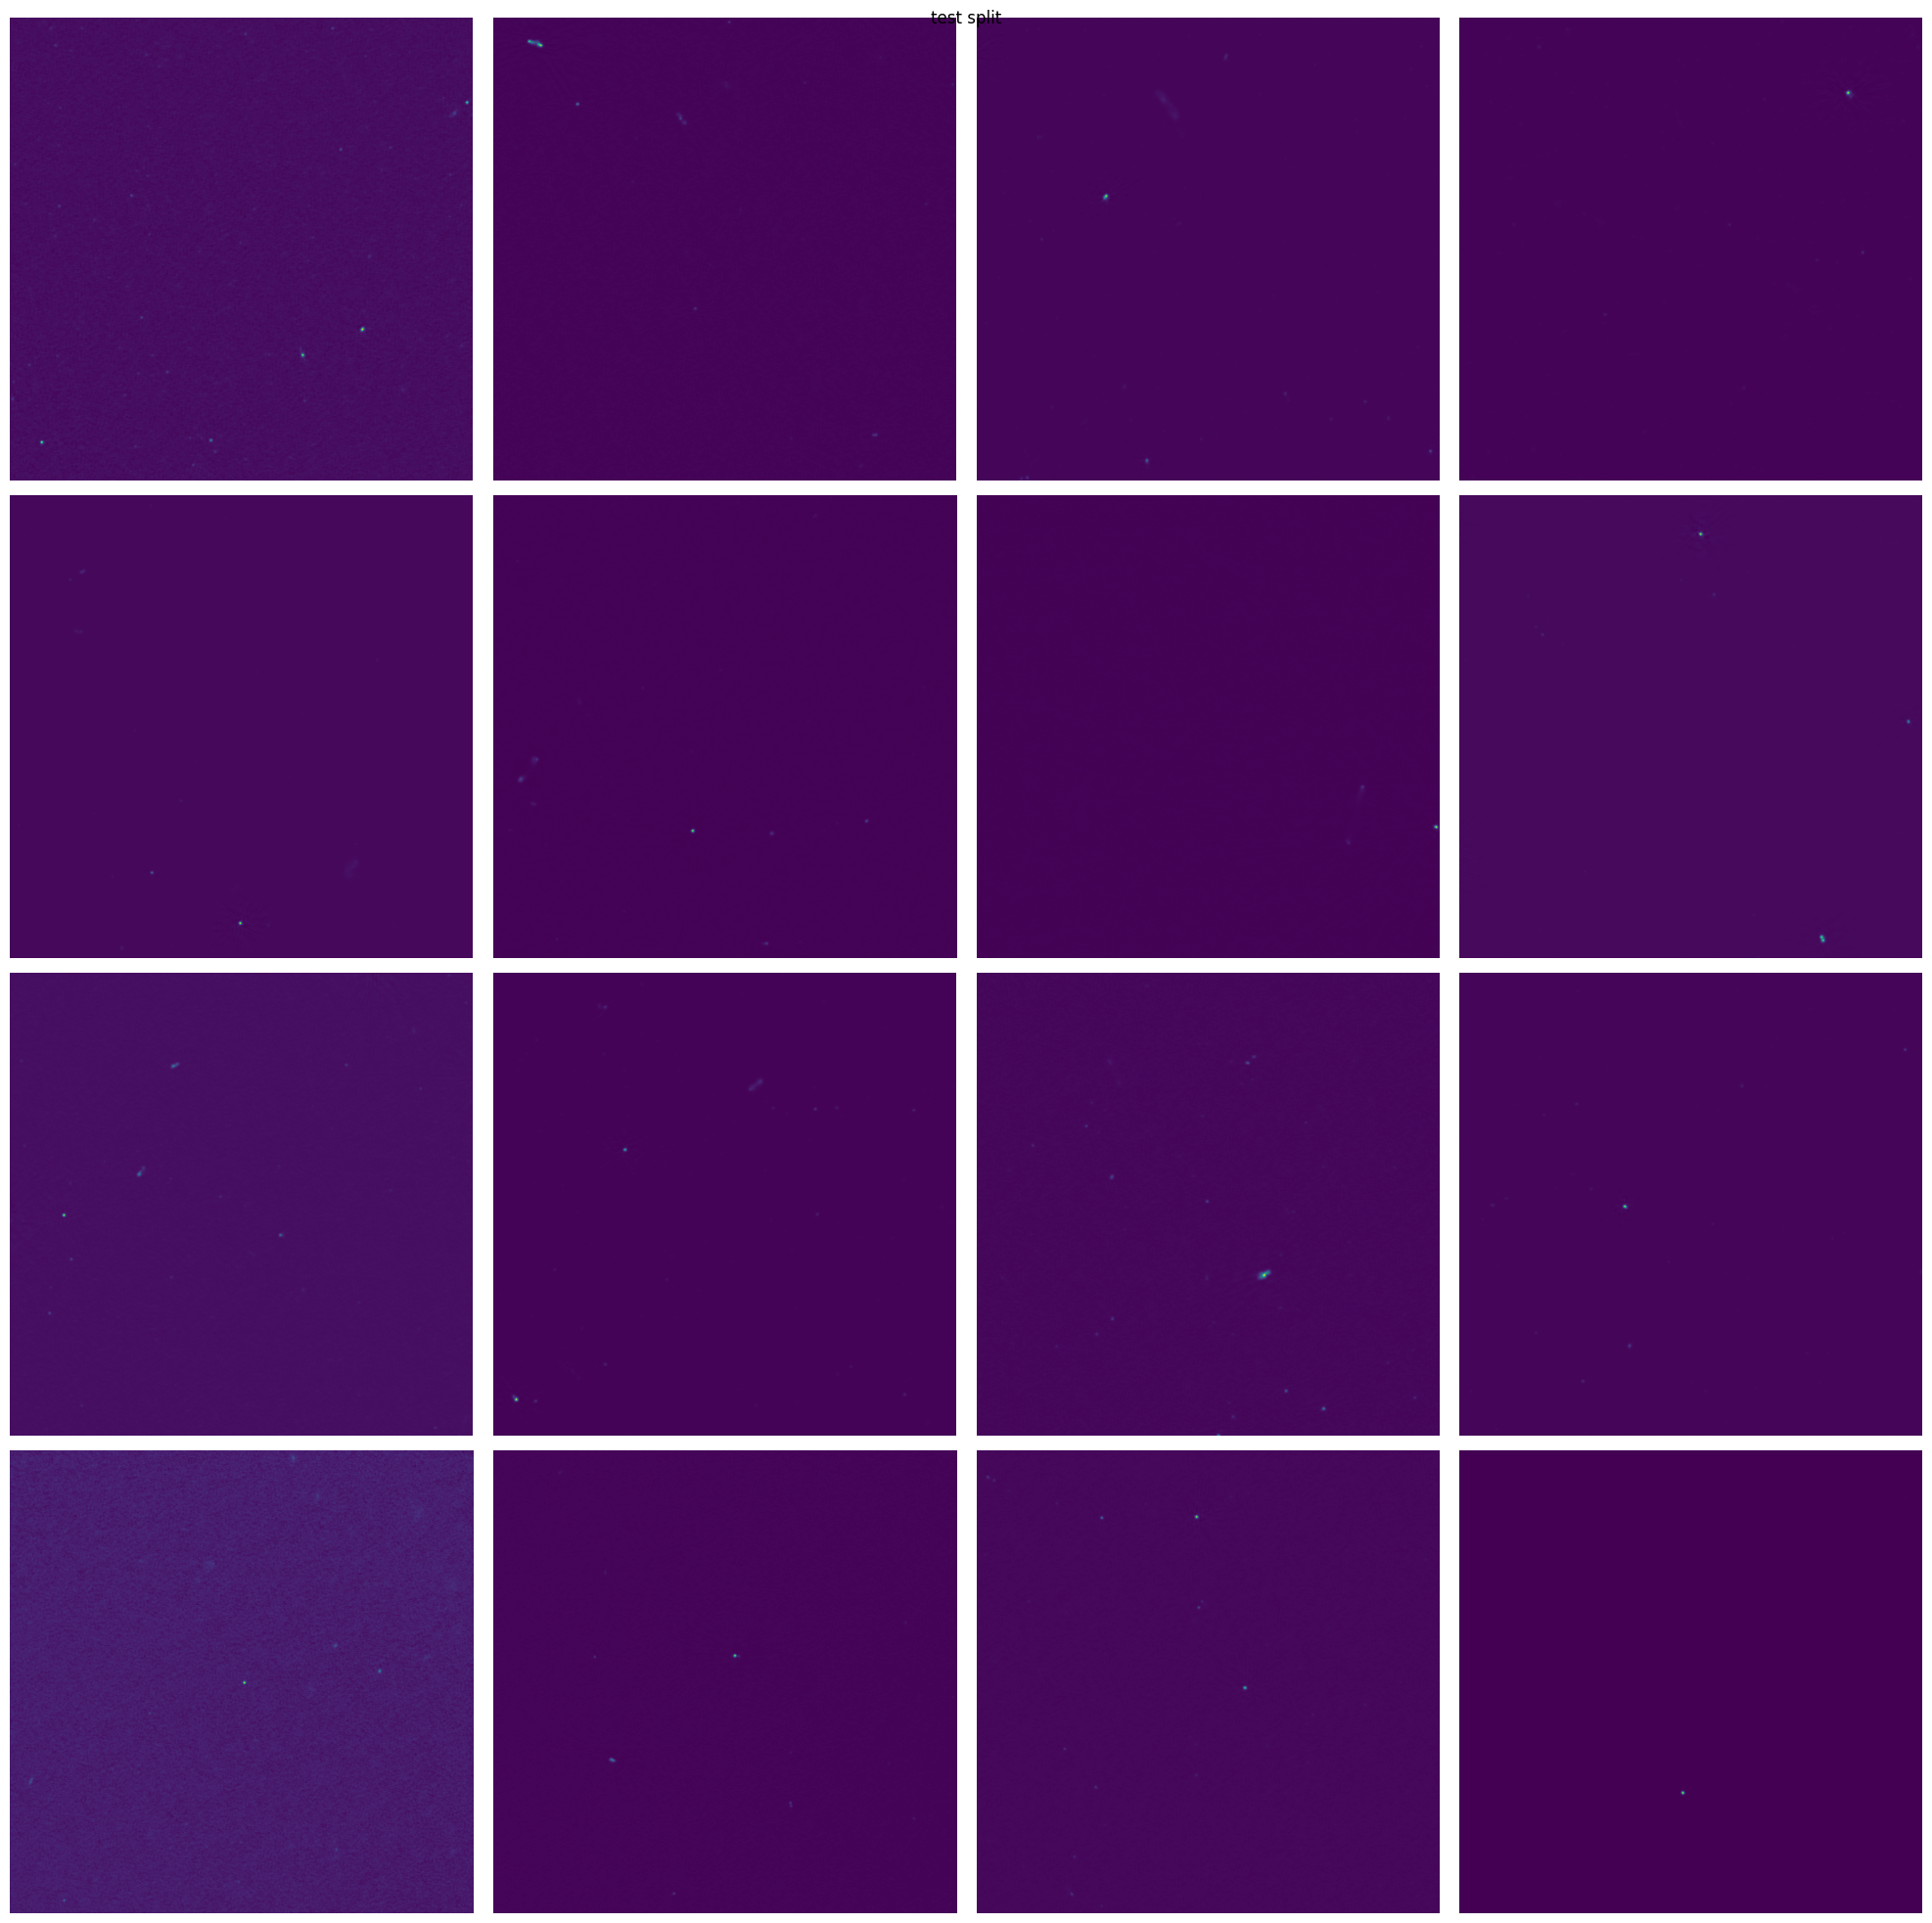

In [15]:
import shutil
from datasets import load_from_disk

from plotting.images import plot_image_grid

# splits = ["train", "val", "test"]
splits = ['test']
dset_parent = paths.LOFAR_DATA_PARENT / 'micromaps-arrow/micromaps-DR3-opt-1024px-spacing=1'

for split in splits:
    split_folder = dset_parent / f"{split}.arrow"
    dataset = load_from_disk(str(split_folder))

    samples = dataset[:16]  # Get the first 16 samples
    images = np.array(samples['npy']) # Extract images from samples
    fig, axs = plot_image_grid(images)
    fig.suptitle(f"{split} split")


In [7]:
# Look at column names
np.array(samples['npy']).shape

(16, 3, 256, 256)

In [4]:
import data.sets.micromaps
from deprecated.datasets import MicromapsDatasetLDM

reload(data.sets.micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import (
    MicromapsDatasetVAE,
    MicromapDatasetHF,
)

import data.trf.transforms as T

reload(T)

import data.trf.functional

reload(data.trf.functional)

from data.trf.scalers import ContextScaler
import data.trf.post as post

from torchvision.transforms.v2 import CenterCrop

reload(post)

# Load Context scalers
ctxt_scaler_keys = ["ctxt_scaler_ftot", "ctxt_scaler_fpeak", "ctxt_scaler_maj"]
ctxt_scalers = scaler_ftot, scaler_fpeak, scaler_maj = [
    ContextScaler.load(k) for k in ctxt_scaler_keys
]

# Output tuple
out = (
    "npy",
    # "context_downscaled.npy",
    # "context_downscaled_d=2_f=2.npy",
    "__key__",
)
# Context transform
ctxt_scale_fn = data.trf.functional.make_catalog_context_value_scale(ctxt_scaler_keys)
ctxt_transform = {
    # "context_downscaled.npy": T.CatalogContextTransform(scale_fn=None),
    # "context_downscaled_d=2_f=2.npy": T.CatalogContextTransform(scale_fn=None),
}

dset_name = "micromap_encodings-DR3-opt-1024"
ldm_dset = MicromapDatasetHF(
    dset_name,
    output_tuple=out,
    split="val",
    ctxt_transform=ctxt_transform,
    # max_beam_arcsec=6.0,
)

 11:45:56 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-opt-1024px-spacing=1_debug/val.arrow
 11:45:56 (MMDsHF) - INFO : Loaded 20 samples
 11:45:56 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 11:45:56 (MMDsHF) - INFO : HuggingFace dataset initialized.


In [ ]:
dset_names = ["micromap-encodings-DR3-512", "micromap-encodings-DR3-1024"]
max_beams = [None, 6.0]
splits = ["train", "val", "test"]

dset_sizes = {}
for max_beam in max_beams:
    print(f"=== Max beam: {max_beam} ===")
    for dset_name in dset_names:
        print(f"--- Dataset: {dset_name} ---")
        split_sizes = {}
        for split in splits:
            dset = MicromapDatasetHF(
                dset_name,
                output_tuple=out,
                split=split,
                ctxt_transform=ctxt_transform,
                max_beam_arcsec=max_beam,
            )
            print(
                f"Dataset: {dset_name} | Split: {split} | Max beam: {max_beam} | Length: {len(dset)}"
            )
            split_sizes[split] = len(dset)
        split_sizes["total"] = sum(split_sizes.values())
        dset_sizes[(dset_name, max_beam)] = split_sizes

 11:45:08 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-512px-spacing=1/train.arrow


=== Max beam: None ===
--- Dataset: micromap-encodings-DR3-512 ---


Loading dataset from disk:   0%|          | 0/256 [00:00<?, ?it/s]

 11:45:17 (MMDsHF) - INFO : Loaded 486_494 samples
 11:45:17 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 11:45:17 (MMDsHF) - INFO : HuggingFace dataset initialized.
 11:45:17 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-512px-spacing=1/val.arrow


Dataset: micromap-encodings-DR3-512 | Split: train | Max beam: None | Length: 486494


...

 11:45:49 (MMDsHF) - INFO : Loaded 13_977 samples
 11:45:49 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 11:45:49 (MMDsHF) - INFO : Dataset has 10_409 samples.
 11:45:49 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 11:45:49 (MMDsHF) - INFO : HuggingFace dataset initialized.
 11:45:49 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-1024px-spacing=1/test.arrow


Dataset: micromap-encodings-DR3-1024 | Split: val | Max beam: 6.0 | Length: 10409


Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

 11:45:49 (MMDsHF) - INFO : Loaded 12_984 samples
 11:45:49 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 11:45:50 (MMDsHF) - INFO : Dataset has 9_616 samples.
 11:45:50 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 11:45:50 (MMDsHF) - INFO : HuggingFace dataset initialized.


Dataset: micromap-encodings-DR3-1024 | Split: test | Max beam: 6.0 | Length: 9616


In [5]:
from pprint import pprint

pprint(dset_sizes)

{('micromap-encodings-DR3-1024', 6.0): {'test': 9616,
                                        'total': 100777,
                                        'train': 80752,
                                        'val': 10409},
 ('micromap-encodings-DR3-1024', None): {'test': 12984,
                                         'total': 135679,
                                         'train': 108718,
                                         'val': 13977},
 ('micromap-encodings-DR3-512', None): {'test': 60063,
                                        'total': 608103,
                                        'train': 486494,
                                        'val': 61546},
 ('micromap-encodings-DR3-512', 6.0): {'test': 44954,
                                       'total': 455489,
                                       'train': 364396,
                                       'val': 46139}}


# Surrounding Sources Ctxt

Load Datasets

In [2]:
import data.sets.micromaps
from deprecated.datasets import MicromapsDatasetLDM

reload(data.sets.micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import (
    MicromapsDatasetVAE,
    MicromapDatasetHF,
)

import data.trf.transforms as T

reload(T)

import data.trf.functional

reload(data.trf.functional)

from data.trf.scalers import ContextScaler
import data.trf.post as post

from torchvision.transforms.v2 import CenterCrop

reload(post)

# Load Context scalers
ctxt_scaler_keys = ["ctxt_scaler_ftot", "ctxt_scaler_fpeak", "ctxt_scaler_maj"]
ctxt_scalers = scaler_ftot, scaler_fpeak, scaler_maj = [
    ContextScaler.load(k) for k in ctxt_scaler_keys
]

# Output tuple
out = (
    "npy",
    "context_downscaled.npy",
    "context_downscaled_d=2_f=2.npy",
    "__key__",
)
# Context transform
ctxt_scale_fn = data.trf.functional.make_catalog_context_value_scale(ctxt_scaler_keys)
ctxt_transform = {
    "context_downscaled.npy": T.CatalogContextTransform(scale_fn=None),
    "context_downscaled_d=2_f=2.npy": T.CatalogContextTransform(scale_fn=None),
}

dset_name = "micromap-encodings-DR3-1024"
ldm_dset = MicromapDatasetHF(
    dset_name,
    output_tuple=out,
    split="train",
    ctxt_transform=ctxt_transform,
    max_beam_arcsec=6.0,
    weights_file="cutout_sampling_probs_fpeak_train.npy",
)
maps_dset = MicromapDatasetHF(
    dset_name.replace("micromap-encodings", "micromaps"),
    split="train",
    output_tuple=(
        "__key__",
        "npy",
    ),
    mode="maps-scaled",
    max_beam_arcsec=6.0,
    weights_file="cutout_sampling_probs_fpeak_train.npy",
)
px_scaler = ldm_dset.scaler

from tqdm import tqdm

# Get weights for sampling batches
sampling_weights = np.array(
    [ldm_dset.weights_dict[key].max() for key in tqdm(ldm_dset.dataset["__key__"])]
)

sampling_weights /= sampling_weights.sum()

 10:46:48 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-1024px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/256 [00:00<?, ?it/s]

 10:46:50 (MMDsHF) - INFO : Loaded 108_718 samples
 10:46:50 (MMDsHF) - INFO : Loading weights from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-1024px-spacing=1/metadata/cutout_sampling_probs_fpeak_train.npy
 10:46:50 (MMDsHF) - INFO : Filtering out 20 samples without weights...
 10:46:54 (MMDsHF) - INFO : Dataset has 108_698 samples.
 10:46:54 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 10:46:58 (MMDsHF) - INFO : Filtering weights_dict accordingly...
 10:47:01 (MMDsHF) - INFO : Dataset has 80_740 samples.
 10:47:01 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 10:47:01 (MMDsHF) - INFO : HuggingFace dataset initialized.
 10:47:01 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromaps-DR3-1024px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/390 [00:00<?, ?it/s]

 10:47:39 (MMDsHF) - INFO : Loaded 108_718 samples
 10:47:39 (MMDsHF) - INFO : Loading weights from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromaps-DR3-1024px-spacing=1/metadata/cutout_sampling_probs_fpeak_train.npy
 10:47:41 (MMDsHF) - INFO : Filtering out 20 samples without weights...
 10:47:45 (MMDsHF) - INFO : Dataset has 108_698 samples.
 10:47:45 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 10:47:50 (MMDsHF) - INFO : Filtering weights_dict accordingly...
 10:47:53 (MMDsHF) - INFO : Dataset has 80_740 samples.
 10:47:53 (MMDsHF) - INFO : Dataset mode set to 'maps-scaled'.
 10:47:53 (MMDsHF) - INFO : HuggingFace dataset initialized.
100%|██████████| 80740/80740 [00:09<00:00, 8623.71it/s]


## Load Samples & Plot

In [ ]:
# Define plotting function
from plotting.images import plot_image_grid


def plot_crops_with_topk(maps, crop_p, topk, shape):
    fig, axs = plot_image_grid(maps, n_cols=2)
    for i, ax in enumerate(axs.flatten()):
        t, l, crop_h, crop_w = crop_p[i]
        # Crop parameters are w.r.t. encoding size (=: shape),
        # Here we translate them to map size.
        # (x, y) is bottom left corner:
        x = l / shape[1] * maps.shape[-1]
        y = t / shape[0] * maps.shape[-2]
        # f_crop := crop_size // original size
        f_crop_h = crop_h / shape[0]
        f_crop_w = crop_w / shape[1]
        # Draw inner crop square
        rect = plt.Rectangle(
            (x, y),
            maps.shape[-1] * f_crop_w,
            maps.shape[-2] * f_crop_h,
            linewidth=0.5,
            edgecolor="r",
            facecolor="none",
            alpha=0.8,
            ls="--",
        )
        ax.add_patch(rect)
        # Draw outer crop square
        ctr = rect.get_center()
        x0, y0, x1, y1 = (
            ctr[0] - maps.shape[-1] * f_crop_w,
            ctr[1] - maps.shape[-2] * f_crop_h,
            ctr[0] + maps.shape[-1] * f_crop_w,
            ctr[1] + maps.shape[-2] * f_crop_h,
        )
        rect = plt.Rectangle(
            (x0, y0),
            maps.shape[-1] * f_crop_w * 2,
            maps.shape[-2] * f_crop_h * 2,
            linewidth=0.8,
            edgecolor="r",
            facecolor="none",
            alpha=0.8,
            ls="--",
        )
        ax.add_patch(rect)
        # xy coordinates (between -1 and 1)
        tpk = topk[i]
        dy, dx = tpk[:, 0], tpk[:, 1]

        # Scatter on respective positions
        ax.scatter(
            x0 + (dx + 1) / 2 * (x1 - x0),
            y0 + (dy + 1) / 2 * (y1 - y0),
            color="r",
            s=25,
            alpha=0.5,
            marker="x",
        )
        ax.set_title(f"{i + 1}", color="r")
    fig.show()

In [3]:
import torch

batch_size = 16
i_batch = np.random.choice(
    len(ldm_dset), size=batch_size, replace=False, p=sampling_weights
)
batch = ldm_dset.get_samples(i_batch)

# Simulate post-transform steps, but with larger cutout size of the image
imgs, img_ctxt, cat_ctxt, keys = batch
_, maps = maps_dset.get_samples(i_batch)
# Double size of the image --> No crop.
# For catalog context, proceed as in training
import data.trf.post as post

reload(post)

# Pre-define random crops
f, s = 2, 2
crop_size = 128
shape = imgs.shape[-2:]
crop_p = np.array(
    [
        post.random_crop_generator(shape, crop_size, f=f, s=s)
        for _ in range(imgs.shape[0])
    ]
)

# ic = image context, cc = catalog context
crop_p_ic = np.array([post.crop_params_f_transform(p, 1, 1, shape) for p in crop_p])
crop_p_cc = np.array([post.crop_params_f_transform(p, f, s, shape) for p in crop_p])
crop_p_map = np.array([post.crop_params_f_transform(p, 1, 4, shape) for p in crop_p])


# Apply crops
from torchvision.transforms.v2.functional import crop

imgs_cropped = torch.stack([crop(imgs[i], *crop_p[i]) for i in range(imgs.shape[0])])
img_ctxt_cropped = torch.stack(
    [crop(img_ctxt[i], *crop_p_ic[i]) for i in range(img_ctxt.shape[0])]
)
cat_ctxt_cropped = torch.stack(
    [crop(cat_ctxt[i], *crop_p_cc[i]) for i in range(cat_ctxt.shape[0])]
)
maps_cropped = torch.stack(
    [crop(maps[i], *crop_p_map[i]) for i in range(maps.shape[0])]
)

# Zero-out center for catalog context
catalog_context_inp = cat_ctxt_cropped.clone()
zero_padw = catalog_context_inp.shape[-1] // 4
catalog_context_inp[:, :, zero_padw:-zero_padw, zero_padw:-zero_padw] *= 0
# -------------------------------------------------------------------------

reload(post)
topk = post.ctxt_to_topk_functional(cat_ctxt_cropped.clone(), k=5, min_val=0, pad=1)

plot_crops_with_topk(maps, crop_p, topk, shape)

KeyboardInterrupt: 

Plot cutouts:

In [ ]:
_ = plot_image_grid(
    maps_cropped.numpy(),
    n_cols=4,
)

Plot Context:

In [ ]:
fig, axs = plot_image_grid(
    catalog_context_inp.reshape(-1, *catalog_context_inp.shape[-2:]), n_cols=4
)

for ax in axs.flatten():
    mask = catalog_context_inp[0, 0] == 0
    ax.contour(mask, colors="red", levels=[0.5], linewidths=0.5)

### Visualize activations

Load denoiser

In [ ]:
import models.diffusion.denoiser

reload(models.diffusion.denoiser)

from models.diffusion.denoiser import Denoiser
from models.utils import parse_lightning_ckpt

import models.networks.modules as modules

reload(modules)

import models.networks.unet as unet

reload(unet)

model_name = "LDM-Denoiser-WnetCC-v3_1"
which = "last-best"

ckpt = parse_lightning_ckpt(which, model_name)
print(f"Loading checkpoint from:\n\t{ckpt}")
denoiser = Denoiser.load_from_checkpoint(ckpt, map_location="cpu")

Call catalog embedding
(Make sure the plotting stuff was run first)

In [ ]:
from tqdm import tqdm, trange
from models.networks.modules import ResidualBlockAttention

device = "cuda:2"
denoiser.eval()
denoiser.to(device)

i_block = 0
# Current model has 3 resolution levels with 2 attention levels. This
# Depends on the model architecture!
res_lvl = i_block + 1
ch_init = 128
px_init = imgs_cropped.shape[-1]

# Set up test feature map
B = topk.shape[0]
K = topk.shape[1]
ch = ch_init * (2**res_lvl)
px = px_init // (2**res_lvl)


# Accumulate attention weights
n_samples = 100
# all_sigmas = (torch.randn([n_samples, B, 1, 1, 1]) * 1.2 - 1.2).exp()
all_sigmas = torch.ones([n_samples, B, 1, 1, 1]) * 50
mask = torch.ones(B, 1, px_init, px_init)
masked_img = torch.zeros_like(imgs_cropped)
img_context = torch.cat((img_ctxt_cropped, masked_img, mask), dim=1)
# catalog_context = topk.to(device)
catalog_context_inp = catalog_context_inp.to(device)


mm = denoiser.model.model
attn_accum = torch.zeros(B, px**2, K, device=device)

with torch.no_grad():
    # Emulate steps through U-Net
    catalog_context_emb = mm.catalog_emb(catalog_context_inp)

    for i in trange(n_samples):
        break
        # Apply noise to images, concatenate image context
        sigmas = all_sigmas[i]
        # print(sigmas.shape)
        n = torch.randn_like(imgs_cropped) * sigmas

        x = imgs_cropped + n
        x = torch.cat((x, img_context), dim=1).to(device)

        # Time (i.e. noise level) embedding
        emb = mm.time_emb(sigmas.flatten().to(device))
        emb = mm.feature_emb(emb)

        # Initial convolution
        x = mm.init_conv(x)
        # h = [x]

        # Go through blocks (atm. only input)
        cross_attn_index = 0
        for module in mm.down_blocks:
            x = module(x, emb)
            if type(module).__name__ == "ResidualBlockAttention":
                cross_attn = mm.cross_attn_blocks[cross_attn_index]
                x, attn_weights = cross_attn(x, catalog_context_emb, need_weights=True)
                print(attn_weights.shape)
                attn_accum += attn_weights
                cross_attn_index += 1
                if cross_attn_index > i_block:
                    break

attn_weights = attn_accum / n_samples

# Move everything back to cpu
denoiser.cpu()
all_sigmas = all_sigmas.cpu()
img_context = img_context.cpu()
catalog_context_inp = catalog_context_inp.cpu()
catalog_context_emb = catalog_context_emb.cpu()
attn_accum = attn_accum.cpu()
# del emb, attn_weights

Plot encoder layer activations:

In [ ]:
from plotting.images import plot_image_grid

plot_grid = []
# Crop pad will be cropped away on the sides
crop_pad = catalog_context_emb.shape[-1] // 4
for i in range(catalog_context_emb.shape[0]):
    plot_grid.extend(
        [
            maps_cropped[i].numpy(),
            *(
                catalog_context_emb[i].numpy()[
                    :, crop_pad:-crop_pad, crop_pad:-crop_pad
                ]
            ),
        ]
    )

_ = plot_image_grid(
    plot_grid,
    n_cols=5,
    # vmin=-3, vmax=3
)

### Resample Encodings

Load Sampler:

In [ ]:
import models.diffusion.denoiser

reload(models.diffusion.denoiser)
import models.diffusion.sampler

reload(models.diffusion.sampler)
import models.ldm.sampler

reload(models.ldm.sampler)
import models.diffusion.diffusion

reload(models.diffusion.diffusion)
import models.utils

reload(models.utils)
from models.ldm.sampler import LDMSampler

ldm_sampler = LDMSampler(
    denoiser=model_name,
    denoiser_ckpt="best",
    device="cuda:1",
    uncond_denoiser="LDM-Denoiser-Uncond-128",
    uncond_denoiser_ckpt="best-last-10",
    image_size=maps_cropped.shape[-1],
    latent_size=imgs_cropped.shape[-1],
)

Re-Sample cutouts:

In [ ]:
import models.diffusion.diffusion

reload(models.diffusion.diffusion)
import models.diffusion.sampler

reload(models.diffusion.sampler)

encodings = imgs_cropped
cat_ctxt = catalog_context_inp
enc_ctxt = img_ctxt_cropped
batch_maps = maps_cropped.numpy()

# Prepare mask (1 means quadrant will be sampled)
mask = torch.tensor([0, 1, 1, 1]).reshape(1, 1, 2, 2).float()
mask = torch.nn.functional.interpolate(
    mask, scale_factor=encodings.shape[-1] // 2, mode="nearest"
)
mask = mask.repeat(encodings.shape[0], 1, 1, 1)


samples = ldm_sampler.sample(
    mask_input=(mask, encodings),
    catalog_context=cat_ctxt,
    context=enc_ctxt,
    # context= torch.zeros_like(enc_ctxt),
    # context=None,
    guidance_strength=0.2,
    rescale=False,
)

layout_kw = dict(n_rows=4)
fig, axs = plot_image_grid(samples, **layout_kw)
# Add lines indicating quadrants:
for ax in axs.flatten():
    kw = dict(color="white", linestyle=":", alpha=0.1)
    x = samples.shape[-1] // 2
    ax.axhline(x, **kw)
    ax.axvline(x, **kw)
plot_image_grid(batch_maps, **layout_kw)

plot_image_grid(ldm_sampler.px_scaler.inverse_scale(samples), **layout_kw)
plot_image_grid(ldm_sampler.px_scaler.inverse_scale(batch_maps), **layout_kw)

# Inspect intermediate results

Load intermediate results

In [ ]:
run_name = "large-bit"

path = list((paths.ANALYSIS_PARENT / "ldm").glob(f"*{run_name}*"))[-1]

import torch

intermediate_results = torch.load(
    sorted(list((path / "intermediates").glob("*.pt")))[1]
)

enc = intermediate_results["encodings"]
ctxt = intermediate_results["context"]
ext_ctxt = intermediate_results["ext_context"]
imgs = intermediate_results["decoded_images"]
masks = intermediate_results["sampling_masks"]

In [ ]:
intermediate_results.keys()

## Plot results

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(masks.transpose(0, 1)[0])

In [ ]:
imgs.shape

In [ ]:
imgs0 = imgs.transpose(0, 1)[0].squeeze()

_ = plot_image_grid(imgs0, vmin=imgs0.min(), vmax=imgs0.max())

In [ ]:
ctxt = intermediate_results["context"]
ctxt.shape

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2)

for i, ch in enumerate(ctxt.permute(2, 0, 1, 3, 4)):
    axs.ravel()[i].hist(ch.flatten(), log=True)

fig.suptitle("Context values")
fig.show()

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2)

for i, ch in enumerate(ext_ctxt.permute(2, 0, 1, 3, 4)):
    axs.ravel()[i].hist(ch.flatten(), log=True)

fig.suptitle("Extended context values")
fig.show()

## Re-sample

Load Sampler

In [ ]:
from models.ldm.sampler import LDMSampler

model_name = "LDM-Denoiser-WnetCC"

ldm_sampler = LDMSampler(
    denoiser=model_name,
    denoiser_ckpt="best",
    device="cuda:1",
    uncond_denoiser="LDM-Denoiser-Uncond-128",
    uncond_denoiser_ckpt="best-last-10",
    image_size=imgs.shape[-1],
    latent_size=enc.shape[-1],
)

In [ ]:
enc.shape, imgs.shape

In [ ]:
# Prepare mask (1 means quadrant will be sampled)
mask = torch.tensor([1, 1, 1, 1]).reshape(1, 1, 2, 2).float()
mask = torch.nn.functional.interpolate(
    mask, scale_factor=enc.shape[-1] // 2, mode="nearest"
)
mask = mask.repeat(enc.shape[1], 1, 1, 1)

# Re-sample i-th quadrant
i = 0
samples = ldm_sampler.sample(
    mask_input=(mask, torch.zeros_like(enc[i])),
    catalog_context=ext_ctxt[i],
    context=ctxt[i],
    guidance_strength=0.2,
    rescale=False,
)

In [ ]:
from plotting.images import plot_image_grid

_ = plot_image_grid(samples)
_ = plot_image_grid(imgs[:, i])